In [7]:
!python main.py --model SimpleCNN --transform aug --epoch 200

There are 3362 parameters in this model
Use aug transformer for training

Epoch 1 / 200
train Accuracy: 0.7672413793103449
valid Accuracy: 0.7857142857142857

Epoch 2 / 200
train Accuracy: 0.7672413793103449
valid Accuracy: 0.7857142857142857

Epoch 3 / 200
train Accuracy: 0.7672413793103449
valid Accuracy: 0.7857142857142857

Epoch 4 / 200
train Accuracy: 0.7672413793103449
valid Accuracy: 0.7857142857142857

Epoch 5 / 200
train Accuracy: 0.7672413793103449
valid Accuracy: 0.7857142857142857

Epoch 6 / 200
train Accuracy: 0.7672413793103449
valid Accuracy: 0.7857142857142857

Epoch 7 / 200
train Accuracy: 0.7672413793103449
valid Accuracy: 0.7857142857142857

Epoch 8 / 200
train Accuracy: 0.7672413793103449
valid Accuracy: 0.7857142857142857

Epoch 9 / 200
train Accuracy: 0.7672413793103449
valid Accuracy: 0.7857142857142857

Epoch 10 / 200
train Accuracy: 0.7672413793103449
valid Accuracy: 0.7857142857142857

Epoch 11 / 200
train Accuracy: 0.7672413793103449
valid Accuracy: 0.7857142


100%|██████████| 2/2 [00:00<00:00, 10.48it/s]

100%|██████████| 1/1 [00:00<00:00, 39.59it/s]

100%|██████████| 2/2 [00:00<00:00, 10.07it/s]

100%|██████████| 1/1 [00:00<00:00, 47.14it/s]

100%|██████████| 2/2 [00:00<00:00,  8.93it/s]

100%|██████████| 1/1 [00:00<00:00, 47.00it/s]

100%|██████████| 2/2 [00:00<00:00, 10.86it/s]

100%|██████████| 1/1 [00:00<00:00, 47.98it/s]

100%|██████████| 2/2 [00:00<00:00, 10.89it/s]

100%|██████████| 1/1 [00:00<00:00, 47.96it/s]

100%|██████████| 2/2 [00:00<00:00, 11.32it/s]

100%|██████████| 1/1 [00:00<00:00, 47.94it/s]

100%|██████████| 2/2 [00:00<00:00, 10.79it/s]

100%|██████████| 1/1 [00:00<00:00, 46.12it/s]

100%|██████████| 2/2 [00:00<00:00, 10.22it/s]

100%|██████████| 1/1 [00:00<00:00, 42.26it/s]

100%|██████████| 2/2 [00:00<00:00, 10.16it/s]

100%|██████████| 1/1 [00:00<00:00, 46.13it/s]

100%|██████████| 2/2 [00:00<00:00, 10.61it/s]

100%|██████████| 1/1 [00:00<00:00, 49.72it/s]

100%|██████████| 2/2 [00:00<00:00, 10.89it/s]

100%|███████

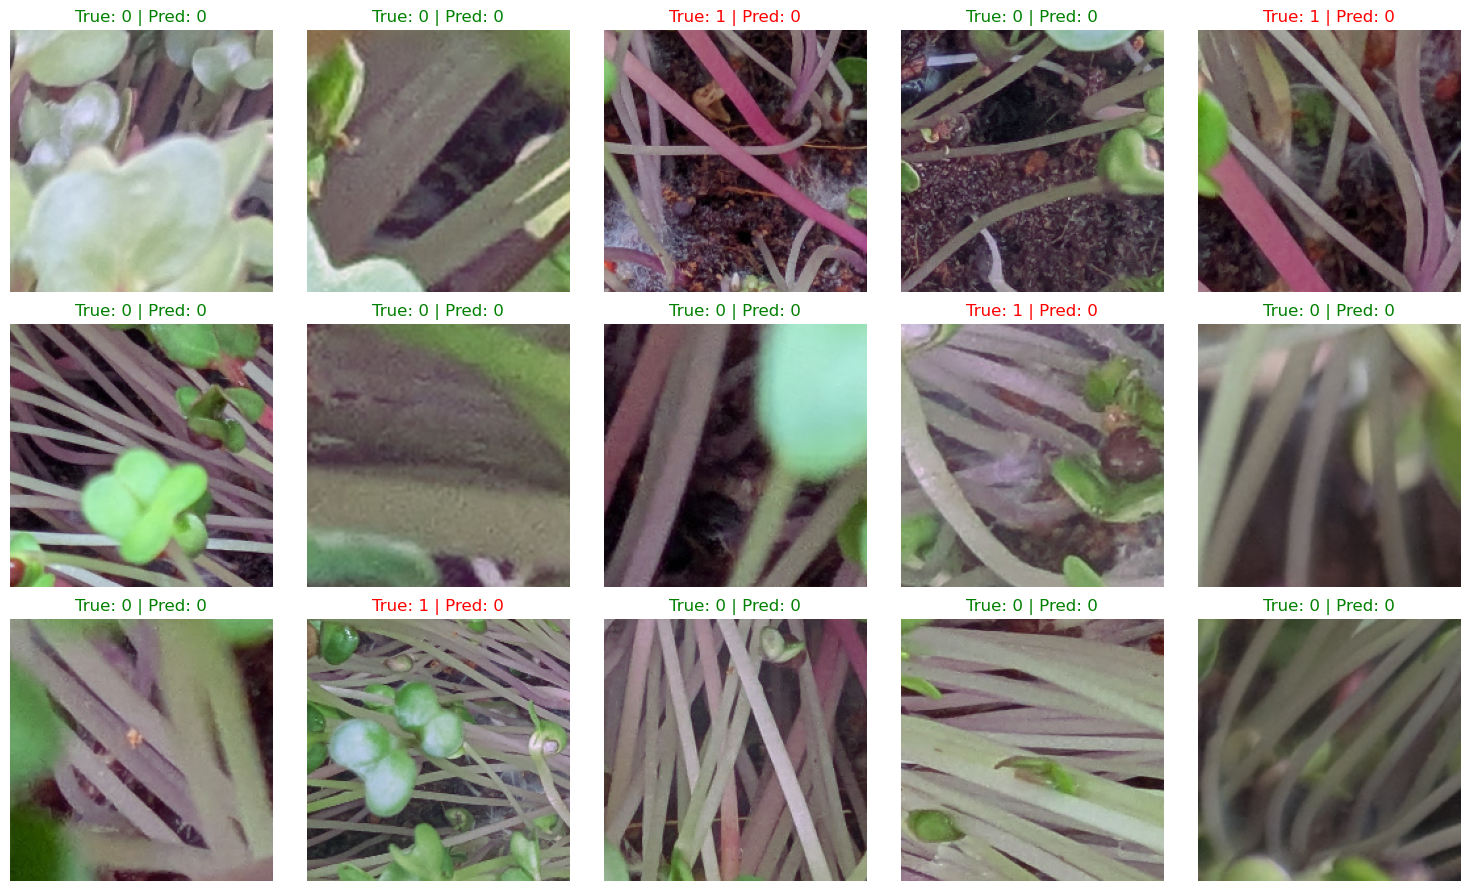

In [9]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
from model import SimpleCNN, norm_transformer
import matplotlib.pyplot as plt
from PIL import Image

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

# Load SimpleCNN model
net = SimpleCNN()
net.load_state_dict(torch.load("SimpleCNN.pt"))
net.eval()
if use_cuda:
    net = net.to(device)

# Load test CSV
import pandas as pd
test_df = pd.read_csv("test.csv")

# Plot
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, row in enumerate(test_df.itertuples()):  
    # Load original image
    img = Image.open(row.path)

    input_tensor = norm_transformer(img).unsqueeze(0)
    if use_cuda:
        input_tensor = input_tensor.to(device)

    with torch.no_grad():
        output = net(input_tensor)
        _, pred = torch.max(output, 1)

    axes[i].imshow(img)
    color = 'green' if pred.item() == row.label else 'red'
    axes[i].set_title(f"True: {row.label} | Pred: {pred.item()}", color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()